In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
torch.manual_seed(42)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:{device}")

Using device:cpu


In [6]:
df = pd.read_csv("/content/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.shape


(60000, 785)

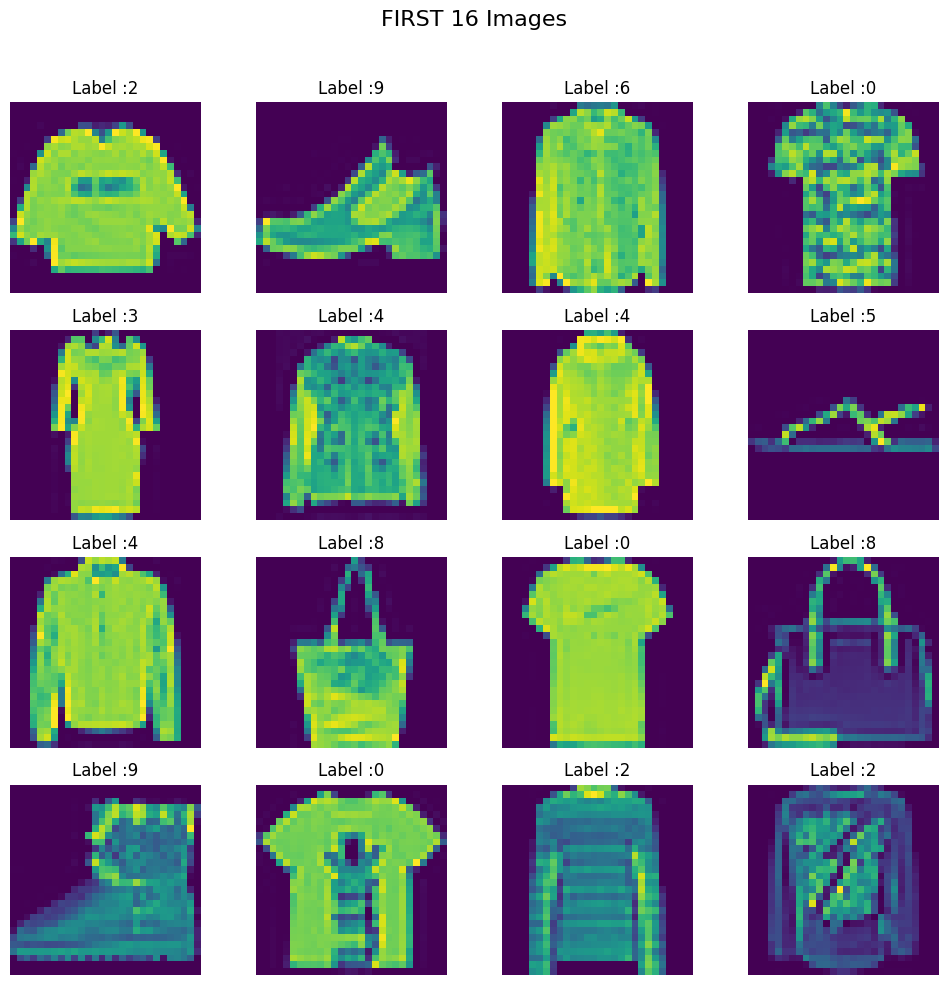

In [8]:
fig, axes = plt.subplots(4,4,figsize =(10,10))
fig.suptitle("FIRST 16 Images",fontsize = 16)

for i ,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label :{df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [9]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [11]:
X_train = X_train/255.0
X_test = X_test/255.0

In [12]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]



In [13]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [14]:
train_loader = DataLoader(train_dataset,batch_size =32,shuffle = True,pin_memory = True)
test_loader = DataLoader(test_dataset,batch_size= 32,shuffle = False,pin_memory=True)


In [15]:
len(train_loader)

1500

In [30]:
class MyNN(nn.Module):
  def __init__(self,input_features):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=32,kernel_size = 3,padding = 'same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size = 2,stride =2),
        nn.Conv2d(32,64,kernel_size = 3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size = 2 , stride = 2)
            )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(64,10)
    )

  def  forward(self,x):
      x = self.features(x)
      x = self.classifier(x)

      return x




In [31]:
learning_rate = 0.01
epochs = 100

In [32]:
model = MyNN(1)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr = learning_rate,weight_decay= 1e-4)


In [ ]:
for epoch in range(epochs):
  total_epochs_loss = 0
  for batch_features ,batch_labels in train_loader:
    batch_features , batch_labels = batch_features.to(device),batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs,batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epochs_loss = total_epochs_loss + loss.item()
  avg_loss = total_epochs_loss / len(train_loader)
  print(f"EPOCHS {epoch +1},loss {avg_loss}")

EPOCHS 1,loss 0.4375460337152084
EPOCHS 2,loss 0.34577479639897746
EPOCHS 3,loss 0.3093813707580169
EPOCHS 4,loss 0.2748846068729957
EPOCHS 5,loss 0.25588937546126544
EPOCHS 6,loss 0.23747815133010347
EPOCHS 7,loss 0.21958724641179045
EPOCHS 8,loss 0.21267536962529024
EPOCHS 9,loss 0.20405253321429093
EPOCHS 10,loss 0.1879256204267343
EPOCHS 11,loss 0.17635706246395905
EPOCHS 12,loss 0.16955179313570262
EPOCHS 13,loss 0.16006811495839307
EPOCHS 14,loss 0.15046632265578955
EPOCHS 15,loss 0.14442294810681294
EPOCHS 16,loss 0.1337643686129401
EPOCHS 17,loss 0.12657310956406095
EPOCHS 18,loss 0.12275731178031614
EPOCHS 19,loss 0.11737453316617757
EPOCHS 20,loss 0.10778092955937608
EPOCHS 21,loss 0.10433824058016762
EPOCHS 22,loss 0.10067175569245591
EPOCHS 23,loss 0.0936853060494177
EPOCHS 24,loss 0.0916966651538775
EPOCHS 25,loss 0.0852565299946582
EPOCHS 26,loss 0.08354593308976231
EPOCHS 27,loss 0.07860604371483593
EPOCHS 28,loss 0.0769157392665511
EPOCHS 29,loss 0.0725086470405998
EPOC